In [33]:
"""
╔══════════════════════════════════════════════════════════════════╗
║  MOLECULAR CLASSIFICATION WITH DEEP LEARNING                    ║
║  LESSON 2: Random Forest, Dynamic Random Forest                ║
║                                                                  ║
║  Three fundamentally different "classical" ML approaches.       ║
║  We compare all of them — and against Logistic Regression.     ║
╚══════════════════════════════════════════════════════════════════╝

WHAT WE LEARN TODAY:
  1. Random Forest — ensemble of decision trees (bagging)

  2. Dynamic Random Forest — ensemble of decision trees (boosting)
"""

'\n╔══════════════════════════════════════════════════════════════════╗\n║  MOLECULAR CLASSIFICATION WITH DEEP LEARNING                    ║\n║  LESSON 2: Random Forest, Dynamic Random Forest                ║\n║                                                                  ║\n║  Three fundamentally different "classical" ML approaches.       ║\n║  We compare all of them — and against Logistic Regression.     ║\n╚══════════════════════════════════════════════════════════════════╝\n\nWHAT WE LEARN TODAY:\n  1. Random Forest — ensemble of decision trees (bagging)\n\n  2. Dynamic Random Forest — ensemble of decision trees (boosting)\n'

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re, math
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import pickle, warnings
warnings.filterwarnings('ignore')

In [35]:
plt.style.use('dark_background')
C = {'LR':   '#38bdf8',
     'RF':   '#34d399',
     'DRF':  '#fbbf24',
     'pos':  '#34d399',
     'neg':  '#f87171',
     'grid': '#1e3a5f',
     'text': '#94a3b8'}
 

In [36]:
import pandas as pd

url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
df = pd.read_csv(url)
# columns: num, name, smiles, p_np
# p_np = 1 (BBB+), 0 (BBB-)
print(df.shape)        # (2050, 4)
print(df.p_np.sum())   # 1568 BBB+


#df = pd.read_csv('mol_dataset.csv')



(2050, 4)
1567


In [37]:
# Trim and rename columns to match our pipeline
df = df[['name', 'smiles', 'p_np']].rename(columns={'p_np': 'bbb'})

# Drop rows with missing SMILES
df = df.dropna(subset=['smiles'])

# Drop protein/peptide sequences (SMILES-only filter)
df = df[df['smiles'].str.len() < 200]
df = df[df['smiles'].str.contains(r'[()=\[\]#\d]|[cnos]', regex=True, na=False)]

# Drop duplicates, reset index
df = df.drop_duplicates(subset='smiles', keep='first').reset_index(drop=True)

# Confirm
print(df.shape)
print(df.columns.tolist())          # ['name', 'smiles', 'bbb']
print(df.head(6).to_string(index=False))
print(f"\nBBB+ : {df.bbb.sum()}  ({df.bbb.mean()*100:.1f}%)")
print(f"BBB- : {(1-df.bbb).sum()}  ({(1-df.bbb.mean())*100:.1f}%)")

(2035, 3)
['name', 'smiles', 'bbb']
                name                                                                                       smiles  bbb
          Propanolol                                                             [Cl].CC(C)NCC(O)COc1cccc2ccccc12    1
Terbutylchlorambucil                                                     C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl    1
               40730                                           c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O    1
                  24                                                             C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C    1
         cloxacillin                           Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O    1
        cefoperazone CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O    1

BBB+ : 1559  (76.6%)
BBB- : 476  (23.4%)


In [38]:
df.head()
print(f"Dataset: {len(df)} molecules")
print(f"BBB Positive (crosses): {df.bbb.sum()}  ({df.bbb.mean()*100:.0f}%)")
print(f"BBB Negative (blocked): {(1-df.bbb).sum()}  ({(1-df.bbb.mean())*100:.0f}%)")
print(f"\nSample molecules:")
print(df[['name','smiles','bbb']].head(6).to_string(index=False))


Dataset: 2035 molecules
BBB Positive (crosses): 1559  (77%)
BBB Negative (blocked): 476  (23%)

Sample molecules:
                name                                                                                       smiles  bbb
          Propanolol                                                             [Cl].CC(C)NCC(O)COc1cccc2ccccc12    1
Terbutylchlorambucil                                                     C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl    1
               40730                                           c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO3)=O    1
                  24                                                             C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C    1
         cloxacillin                           Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)[C@@H](N4C3=O)C(O)=O    1
        cefoperazone CCN1CCN(C(=O)N[C@@H](C(=O)N[C@H]2[C@H]3SCC(=C(N3C2=O)C(O)=O)CSc4nnnn4C)c5ccc(O)cc5)C(=O)C1=O    1


In [39]:
df.head()

,name,smiles,bbb
0,Propanolol,[Cl].CC(C)NCC(O)COc1cccc2ccccc12,1
1,Terbutylchlorambucil,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl,1
2,40730,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...,1
3,24,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C,1
4,cloxacillin,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...,1


In [40]:
#building our own feature vector not using rdkit :


# ═══════════════════════════════════════════════════════════════════
# STEP 2 — SMILES FEATURISATION (Building Our Own "Fingerprint")
# ═══════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("  STEP 2: SMILES → FEATURE VECTOR")
print("=" * 65)
print("""
A SMILES string encodes rich chemical information as text.
We extract features from this text — just like NLP feature engineering.

FEATURE CATEGORIES:
  A) Atom counts       — how many C, N, O, S, F, Cl, Br atoms
  B) Bond/structure    — rings, double bonds, aromatic bonds
  C) Physicochemical   — molecular weight (approx), logP proxy
  D) Text n-grams      — character bigrams (Jardim et al. approach)
  E) Rule-of-5 flags   — Lipinski drug-likeness rules
""")


  STEP 2: SMILES → FEATURE VECTOR

A SMILES string encodes rich chemical information as text.
We extract features from this text — just like NLP feature engineering.

FEATURE CATEGORIES:
  A) Atom counts       — how many C, N, O, S, F, Cl, Br atoms
  B) Bond/structure    — rings, double bonds, aromatic bonds
  C) Physicochemical   — molecular weight (approx), logP proxy
  D) Text n-grams      — character bigrams (Jardim et al. approach)
  E) Rule-of-5 flags   — Lipinski drug-likeness rules



In [41]:
# Atomic weights for MW estimation
ATOM_WEIGHTS = {'C': 12.0, 'N': 14.0, 'O': 16.0, 'S': 32.0,
                'F': 19.0, 'Cl': 35.5, 'Br': 80.0, 'I': 127.0,
                'P': 31.0, 'H': 1.0}
#these weights are used for a quick estimation of molecular weight based on atom counts.
#how did we chose these weights? They are rounded atomic weights of the elements commonly found in drug-like molecules. Sources ? IUPAC and standard atomic weights from chemistry references.
#  We include H (hydrogen) for better MW estimation, even though it's often implicit in SMILES. 
# This allows us to estimate the molecular weight without needing a full chemistry toolkit, which is useful for our custom featurisation approach.

In [42]:

# Hydrophobicity contribution (Crippen logP fragments — simplified)
LOGP_CONTRIB = {'C': 0.53, 'c': 0.13, 'N': -1.03, 'n': -0.57,
                'O': -0.67, 'o': -0.32, 'S': 0.03, 'F': 0.14,
                'Cl': 0.60, 'Br': 0.88, 'I': 1.35, 'P': 0.22}

# These contributions are based on the Crippen logP fragment values, which assign a hydrophobicity contribution to each atom type.
# We use these values to estimate the overall logP of the molecule, which is a key factor in BBB permeability.
# The values are simplified and may not capture all nuances, but they provide a useful proxy for our featurisation without needing a full chemistry toolkit.


In [43]:
def smiles_to_features(smiles):
    """
    Convert a SMILES string to a numerical feature vector.
    
    This is the core of feature-engineered molecular classification.
    Every feature has a chemical meaning.
    """
    s = smiles

    # ── A: ATOM COUNTS ─────────────────────────────────────────────
    n_C  = len(re.findall(r'[Cc]', s)) # count both uppercase and lowercase C for total carbon count in the string s.
    n_N  = len(re.findall(r'[Nn]', s))
    n_O  = len(re.findall(r'[Oo]', s))
    n_S  = len(re.findall(r'[Ss]', s))
    n_F  = s.count('F')
    n_Cl = s.count('Cl')
    n_Br = s.count('Br')
    n_I  = s.count('I')
    n_P  = s.count('P')

    # ── B: BOND & TOPOLOGY FEATURES ────────────────────────────────
    n_double   = s.count('=')          # double bonds
    n_triple   = s.count('#')          # triple bonds
    n_aromatic = len(re.findall(r'[a-z]', s))  # lowercase = aromatic
    n_rings    = len(re.findall(r'\d', s)) // 2  # ring closure digits
    n_branches = s.count('(')          # branch points
    n_charged  = s.count('+') + s.count('-')    # charges

    # ── C: MOLECULAR WEIGHT (approximate) ─────────────────────────
    mw = 0.0
    for atom, wt in ATOM_WEIGHTS.items():
        if len(atom) == 2:
            mw += s.count(atom) * wt
            #why? We check for two-character atoms (like Cl, Br) first to avoid double-counting the 'C' and 'l' in 'Cl' or 'B' and 'r' in 'Br'.
            #  If we counted single characters first, we would count the 'C' in 'Cl' as a carbon atom, which would inflate our carbon count
            #  and thus our molecular weight estimation. By counting two-character atoms first, we ensure that we correctly identify and count these specific elements without confusion.
        else:
            # single-letter — avoid double-counting Cl, Br
            count = len(re.findall(f'(?<![A-Z]){atom}(?!l|r)', s))
            mw += count * wt
    # Add implicit hydrogens (rough estimate)
    n_heavy = n_C + n_N + n_O + n_S + n_F + n_Cl + n_Br + n_I + n_P #why? We calculate the total number of heavy atoms (non-hydrogen) in the molecule.
    #This is done by summing the counts of all the atoms we identified in the previous steps.
    mw += n_heavy * 1.0 * 1.5  # H approximation

    # ── D: logP PROXY (hydrophilicity / lipophilicity) ─────────────
    logp = sum(LOGP_CONTRIB.get(c, 0) for c in s)

    # ── E: POLAR SURFACE AREA proxy (H-bond donors/acceptors) ──────
    hbd = len(re.findall(r'[OH]|N(?!.*\()', s))   # H-bond donors
    hba = len(re.findall(r'[NO]', s))              # H-bond acceptors

    # ── F: LIPINSKI RULE-OF-5 FLAGS ────────────────────────────────
    # Oral bioavailability proxy — MW<500, logP<5, HBD≤5, HBA≤10
    ro5_mw   = 1 if mw < 500 else 0
    ro5_logp = 1 if logp < 5  else 0
    ro5_hbd  = 1 if hbd <= 5  else 0
    ro5_hba  = 1 if hba <= 10 else 0
    ro5_pass  = ro5_mw + ro5_logp + ro5_hbd + ro5_hba  # 0-4 rules passed

    # ── G: TEXT N-GRAMS (Jardim et al. approach) ───────────────────
    # Count character bigrams in the SMILES string
    # This captures local chemical context without explicit parsing
    BIGRAMS = ['CC', 'CN', 'CO', 'CS', 'C=', 'C(', 'C1', 'c1', 'c2',
               'cc', 'NC', 'OC', 'O=', 'N=', 'Cl', 'Br', '=O', '=N',
               'C#', 'c(', 'n1', 'N1', 'OC', 'SC', 'FC', 'C)', 'O)']
    bigram_counts = [s.count(bg) for bg in BIGRAMS]

    # ── H: STRUCTURAL COMPLEXITY ────────────────────────────────────
    smiles_len   = len(s)
    unique_atoms = len(set(re.findall(r'[A-Za-z]', s)))
    frac_arom    = n_aromatic / max(smiles_len, 1)  # aromaticity fraction

    # Assemble feature vector
    features = [
        # Atom counts (9)
        n_C, n_N, n_O, n_S, n_F, n_Cl, n_Br, n_I, n_P,
        # Bonds/topology (6)
        n_double, n_triple, n_aromatic, n_rings, n_branches, n_charged,
        # Physicochemical (5)
        mw, logp, hbd, hba, ro5_pass,
        # Lipinski flags (4)
        ro5_mw, ro5_logp, ro5_hbd, ro5_hba,
        # Complexity (3)
        smiles_len, unique_atoms, frac_arom,
        # Bigrams (28)
        *bigram_counts
    ]
    return np.array(features, dtype=float)




In [44]:
FEATURE_NAMES = (
    ['n_C','n_N','n_O','n_S','n_F','n_Cl','n_Br','n_I','n_P'] +
    ['n_double','n_triple','n_aromatic','n_rings','n_branches','n_charged'] +
    ['mol_weight','logP_proxy','HBD','HBA','ro5_passed'] +
    ['ro5_mw','ro5_logp','ro5_hbd','ro5_hba'] +
    ['smiles_len','unique_atoms','frac_aromatic'] +
    [f'bigram_{i}' for i in range(28)]
)
# Apply to all molecules
X = np.array([smiles_to_features(s) for s in df['smiles']])
y = df['bbb'].values

print(f"Feature matrix shape: {X.shape}")
print(f"  → {X.shape[0]} molecules × {X.shape[1]} features")
print(f"\nExample: Aspirin features (first 20)")
#aspirin_idx = df[df.name == 'Aspirin'].index[0]
#for name, val in zip(FEATURE_NAMES[:20], X[aspirin_idx, :20]):
    #print(f"  {name:<20} = {val:.2f}")

Feature matrix shape: (2035, 54)
  → 2035 molecules × 54 features

Example: Aspirin features (first 20)


In [45]:
print("\n" + "=" * 65)
print("  ALGORITHM 2: RANDOM FOREST")
print("=" * 65)
print("""
IDEA: Train N independent decision trees, each on a random subset 
of data AND features. Predict by majority vote.

WHY RANDOM?
  → Each tree sees different data  (bootstrap sampling = "bagging")
  → Each split considers random subset of features (reduces correlation)
  → Many weak learners → one strong learner

FOR MOLECULES:
  → Each tree learns different substructure rules
  → Tree 1: "if n_aromatic > 3 AND logP > 2 → BBB+"
  → Tree 2: "if mol_weight < 300 AND n_O < 3 → BBB+"
  → Final prediction: majority vote of all trees

KEY HYPERPARAMETERS:
  n_estimators   = number of trees (more = better, but slower)
  max_depth      = how deep each tree grows (controls overfitting)
  max_features   = features considered per split (sqrt(n) default)
""")


  ALGORITHM 2: RANDOM FOREST

IDEA: Train N independent decision trees, each on a random subset 
of data AND features. Predict by majority vote.

WHY RANDOM?
  → Each tree sees different data  (bootstrap sampling = "bagging")
  → Each split considers random subset of features (reduces correlation)
  → Many weak learners → one strong learner

FOR MOLECULES:
  → Each tree learns different substructure rules
  → Tree 1: "if n_aromatic > 3 AND logP > 2 → BBB+"
  → Tree 2: "if mol_weight < 300 AND n_O < 3 → BBB+"
  → Final prediction: majority vote of all trees

KEY HYPERPARAMETERS:
  n_estimators   = number of trees (more = better, but slower)
  max_depth      = how deep each tree grows (controls overfitting)
  max_features   = features considered per split (sqrt(n) default)



In [46]:
X

array([[17.,  1.,  2., ...,  0.,  1.,  1.],
       [20.,  1.,  2., ...,  0.,  3.,  1.],
       [18.,  3.,  4., ...,  0.,  2.,  2.],
       ...,
       [18.,  4.,  2., ...,  0.,  0.,  1.],
       [22.,  2.,  4., ...,  0.,  5.,  0.],
       [11.,  5.,  5., ...,  0.,  0.,  4.]])

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2 ,random_state=42, stratify=y
)

In [48]:
# Scaler for LR baseline only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
 
# ═══════════════════════════════════════════════════════════════
# 4.  BASELINE — LOGISTIC REGRESSION
# ═══════════════════════════════════════════════════════════════
print("\n── Logistic Regression ──")
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:,1]
auc_lr    = roc_auc_score(y_test, y_prob_lr)
from sklearn.pipeline import Pipeline
lr_pipe = Pipeline([('sc', StandardScaler()),
                    ('lr', LogisticRegression(C=1.0, max_iter=1000,
                                              random_state=42))])
cv_lr = cross_val_score(lr_pipe, X, y, cv=5, scoring='roc_auc').mean()
print(f"  Test AUC : {auc_lr:.3f}   5-fold CV : {cv_lr:.3f}")
print(classification_report(y_test, y_pred, target_names=['BBB-', 'BBB+']))


── Logistic Regression ──
  Test AUC : 0.949   5-fold CV : 0.889
              precision    recall  f1-score   support

        BBB-       0.82      0.66      0.73        95
        BBB+       0.90      0.96      0.93       312

    accuracy                           0.89       407
   macro avg       0.86      0.81      0.83       407
weighted avg       0.88      0.89      0.88       407



In [49]:
rf = RandomForestClassifier(
    n_estimators=200,    # 200 trees
    max_depth=None,      # grow until pure — RF handles overfitting via ensemble
    max_features='sqrt', # sqrt(54) ≈ 7 features per split
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # RF doesn't need scaled features

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
auc_rf     = roc_auc_score(y_test, y_prob_rf)
cv_rf      = cross_val_score(rf, X, y, cv=5, scoring='roc_auc').mean()


In [50]:
print(f"Random Forest Results:")
print(f"  Test Accuracy : {(y_pred_rf == y_test).mean():.3f}")
print(f"  Test ROC-AUC  : {auc_rf:.3f}")
print(f"  5-fold CV AUC : {cv_rf:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['BBB-', 'BBB+']))

Random Forest Results:
  Test Accuracy : 0.916
  Test ROC-AUC  : 0.972
  5-fold CV AUC : 0.928

Classification Report:
              precision    recall  f1-score   support

        BBB-       0.87      0.76      0.81        95
        BBB+       0.93      0.96      0.95       312

    accuracy                           0.92       407
   macro avg       0.90      0.86      0.88       407
weighted avg       0.91      0.92      0.91       407



In [51]:
# Feature importance (built-in Gini importance)
feat_imp = rf.feature_importances_
FEAT_NAMES = (
    ['n_C','n_N','n_O','n_S','n_F','n_Cl','n_Br','n_I','n_P'] +
    ['n_double','n_triple','n_aromatic','n_rings','n_branches','n_charged'] +
    ['mol_weight','logP_proxy','HBD','HBA','ro5_passed'] +
    ['ro5_mw','ro5_logp','ro5_hbd','ro5_hba'] +
    ['smiles_len','unique_atoms','frac_aromatic'] +
    [f'bigram_{i}' for i in range(28)]
)
top_rf = np.argsort(feat_imp)[::-1][:10]
print(f"\nTop 10 features (Gini importance):")
for i in top_rf:
    print(f"  {FEAT_NAMES[i]:<22} {feat_imp[i]:.4f}  {'█'*int(feat_imp[i]*200)}")


Top 10 features (Gini importance):
  bigram_26              0.0643  ████████████
  n_aromatic             0.0639  ████████████
  logP_proxy             0.0578  ███████████
  frac_aromatic          0.0569  ███████████
  n_O                    0.0546  ██████████
  HBA                    0.0518  ██████████
  HBD                    0.0507  ██████████
  mol_weight             0.0420  ████████
  smiles_len             0.0416  ████████
  bigram_4               0.0328  ██████


In [52]:
# ═══════════════════════════════════════════════════════════════
# 6.  DYNAMIC RANDOM FOREST  (grown until OOB plateaus)
# ═══════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  DYNAMIC RANDOM FOREST")
print("═"*65)
print("""
IDEA: Instead of fixing n_estimators=200 upfront, we grow the
forest one batch at a time and monitor the OOB (out-of-bag) AUC
after each addition. We stop when performance plateaus.
 
WHY DYNAMIC?
  → No need to guess n_estimators — the data decides
  → Stops early if a small forest already generalises well
  → Avoids training thousands of trees you don't need
  → OOB error is a free, unbiased validation estimate
    (each tree is tested only on the ~37% of samples it
     did NOT see during its bootstrap training round)
 
STOPPING CRITERION:
  patience  = 5   rounds with no improvement
  tolerance = 0.001  minimum meaningful AUC gain
  batch     = 10  trees added per round
""")
 
class DynamicRandomForest:
    """
    Grows a Random Forest incrementally, stopping when the
    OOB AUC stops improving. Uses warm_start to add trees
    without retraining existing ones.
    """
    def __init__(self, batch_size=10, min_trees=10, max_trees=500,
                 patience=5, tolerance=1e-3, random_state=42):
        self.batch_size   = batch_size
        self.min_trees    = min_trees
        self.max_trees    = max_trees
        self.patience     = patience
        self.tolerance    = tolerance
        self.random_state = random_state
 
        # warm_start=True lets us add trees without retraining
        self.forest = RandomForestClassifier(
            n_estimators=min_trees,
            max_features='sqrt',
            min_samples_leaf=1,
            oob_score=True,         # free validation at each step
            warm_start=True,        # KEY: reuse existing trees
            random_state=random_state,
            n_jobs=-1)
 
        # History for plotting
        self.history_n_trees = []
        self.history_oob_auc = []
        self.best_n_trees_   = min_trees
        self.best_oob_auc_   = 0.0
        self.rounds_no_improve = 0
        self.stopped_early_    = False
 
    def fit(self, X, y):
        n_trees = self.min_trees
 
        while n_trees <= self.max_trees:
            # Set new target size and fit incrementally
            self.forest.set_params(n_estimators=n_trees)
            self.forest.fit(X, y)
 
            # OOB predictions → AUC (OOB is already held-out)
            oob_proba = self.forest.oob_decision_function_[:, 1]
            oob_auc   = roc_auc_score(y, oob_proba)
 
            self.history_n_trees.append(n_trees)
            self.history_oob_auc.append(oob_auc)
 
            # Improvement check
            if oob_auc > self.best_oob_auc_ + self.tolerance:
                self.best_oob_auc_ = oob_auc
                self.best_n_trees_ = n_trees
                self.rounds_no_improve = 0
            else:
                self.rounds_no_improve += 1
 
            # Early stopping
            if (n_trees >= self.min_trees and
                    self.rounds_no_improve >= self.patience):
                self.stopped_early_ = True
                break
 
            n_trees += self.batch_size
 
        # Roll back to best size
        self.forest.set_params(
            n_estimators=self.best_n_trees_,
            warm_start=False)
        self.forest.fit(X, y)
        return self
 
    def predict(self, X):
        return self.forest.predict(X)
 
    def predict_proba(self, X):
        return self.forest.predict_proba(X)
 
    @property
    def feature_importances_(self):
        return self.forest.feature_importances_
 
 
# ── Train Dynamic RF ─────────────────────────────────────────────
print("Training Dynamic Random Forest on training set...")
drf = DynamicRandomForest(
    batch_size=10, min_trees=10, max_trees=500,
    patience=5, tolerance=0.001, random_state=42)
drf.fit(X_train, y_train)
 
y_pred_drf = drf.predict(X_test)
y_prob_drf  = drf.predict_proba(X_test)[:,1]
auc_drf     = roc_auc_score(y_test, y_prob_drf)
cv_drf      = cross_val_score(
    RandomForestClassifier(n_estimators=drf.best_n_trees_,
                           max_features='sqrt', random_state=42),
    X, y, cv=5, scoring='roc_auc').mean()
 
print(f"\n  Trees trained     : {max(drf.history_n_trees)}")
print(f"  Stopped at        : {drf.best_n_trees_} trees  "
      f"({'early stop' if drf.stopped_early_ else 'max reached'})")
print(f"  Best OOB AUC      : {drf.best_oob_auc_:.3f}")
print(f"  Test AUC          : {auc_drf:.3f}")
print(f"  5-fold CV AUC     : {cv_drf:.3f}")
print(f"\nClassification Report (Dynamic RF):")
print(classification_report(y_test, y_pred_drf, target_names=['BBB-','BBB+']))
 
top_drf = np.argsort(drf.feature_importances_)[::-1][:10]
print("  Top 10 features (Gini importance):")
for i in top_drf:
    bar = '█'*int(drf.feature_importances_[i]*300)
    print(f"    {FEATURE_NAMES[i]:<22} {drf.feature_importances_[i]:.4f}  {bar}")
 


═════════════════════════════════════════════════════════════════
  DYNAMIC RANDOM FOREST
═════════════════════════════════════════════════════════════════

IDEA: Instead of fixing n_estimators=200 upfront, we grow the
forest one batch at a time and monitor the OOB (out-of-bag) AUC
after each addition. We stop when performance plateaus.

WHY DYNAMIC?
  → No need to guess n_estimators — the data decides
  → Stops early if a small forest already generalises well
  → Avoids training thousands of trees you don't need
  → OOB error is a free, unbiased validation estimate
    (each tree is tested only on the ~37% of samples it
     did NOT see during its bootstrap training round)

STOPPING CRITERION:
  patience  = 5   rounds with no improvement
  tolerance = 0.001  minimum meaningful AUC gain
  batch     = 10  trees added per round

Training Dynamic Random Forest on training set...

  Trees trained     : 220
  Stopped at        : 170 trees  (early stop)
  Best OOB AUC      : 0.955
  Test AU

In [53]:
# ═══════════════════════════════════════════════════════════════
# 7.  COMPARISON SUMMARY
# ═══════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  FINAL COMPARISON")
print("═"*65)
results = [
    ("Logistic Regression", auc_lr, cv_lr, "54 weights",     True),
    ("Random Forest (200)", auc_rf, cv_rf, "200 trees",       False),
    (f"Dynamic RF ({drf.best_n_trees_}t)", auc_drf, cv_drf,
     f"{drf.best_n_trees_} trees",  False),
]
print(f"{'Model':<26} {'Test AUC':>9} {'CV AUC':>9} {'Config'}")
print("─"*60)
for name, tauc, cauc, cfg, _ in sorted(results, key=lambda x:-x[1]):
    mark = " ← BEST" if tauc == max(r[1] for r in results) else ""
    print(f"  {name:<24} {tauc:.3f}     {cauc:.3f}     {cfg}{mark}")
 


═════════════════════════════════════════════════════════════════
  FINAL COMPARISON
═════════════════════════════════════════════════════════════════
Model                       Test AUC    CV AUC Config
────────────────────────────────────────────────────────────
  Dynamic RF (170t)        0.972     0.928     170 trees ← BEST
  Random Forest (200)      0.972     0.928     200 trees
  Logistic Regression      0.949     0.889     54 weights


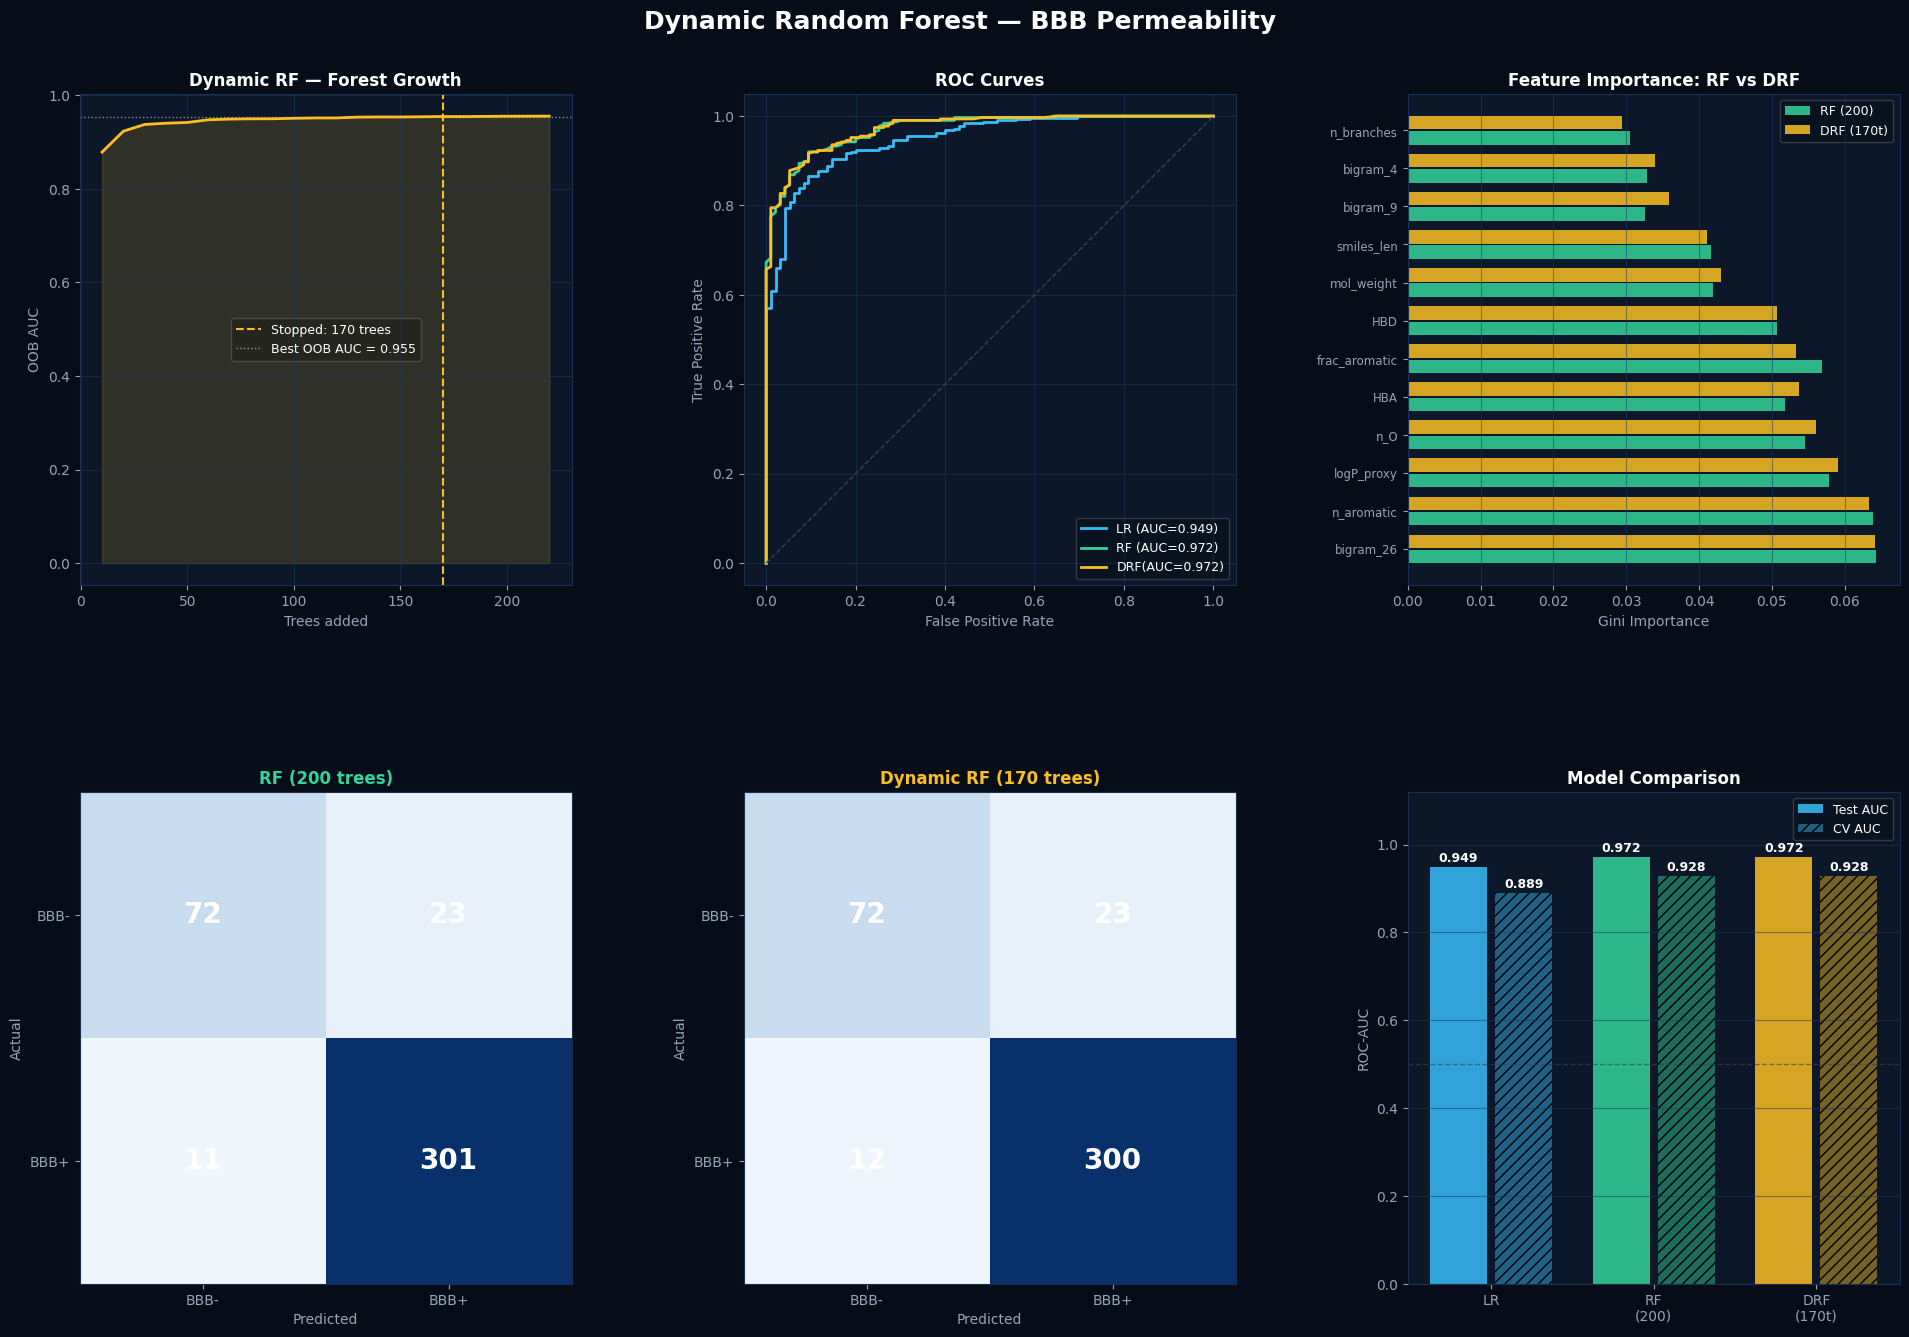


Figure saved → lesson2_dynamic_rf.png

═════════════════════════════════════════════════════════════════
  KEY INSIGHT
═════════════════════════════════════════════════════════════════

Standard RF used 200 trees (fixed, guessed upfront).
Dynamic  RF used 170 trees (stopped when OOB AUC plateaued).

Trees saved : 30  (15% reduction in compute)
AUC change  : +0.000  (RF=0.972  →  DRF=0.972)

This illustrates the Jardim et al. (2024) argument:
  On SMALL datasets, model complexity rarely helps.
  What matters is the FEATURE REPRESENTATION.
  Both RF and DRF are dominated by logP, n_rings,
  and aromatic bigrams — the same features logistic
  regression weights most heavily.



In [54]:
# ═══════════════════════════════════════════════════════════════
# 8.  VISUALISATION  (5-panel figure)
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14), facecolor='#060d18')
fig.suptitle('Dynamic Random Forest — BBB Permeability',
             fontsize=18, fontweight='bold', color='white',
             y=0.98)
 
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35,
                      left=0.06, right=0.97, top=0.92, bottom=0.07)
ax_grow  = fig.add_subplot(gs[0, 0])   # DRF growth curve
ax_roc   = fig.add_subplot(gs[0, 1])   # ROC curves
ax_imp   = fig.add_subplot(gs[0, 2])   # Feature importance
ax_cm_rf = fig.add_subplot(gs[1, 0])   # Confusion matrix RF
ax_cm_drf= fig.add_subplot(gs[1, 1])   # Confusion matrix DRF
ax_bar   = fig.add_subplot(gs[1, 2])   # AUC bar chart
 
bg = '#0c1829'
for ax in [ax_grow, ax_roc, ax_imp, ax_cm_rf, ax_cm_drf, ax_bar]:
    ax.set_facecolor(bg)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1a3050')
 
# ── Panel 1: DRF growth curve ────────────────────────────────
ax_grow.plot(drf.history_n_trees, drf.history_oob_auc,
             color=C['DRF'], lw=2, zorder=3)
ax_grow.fill_between(drf.history_n_trees, drf.history_oob_auc,
                     alpha=0.15, color=C['DRF'])
ax_grow.axvline(drf.best_n_trees_, color=C['DRF'], ls='--', lw=1.5,
                label=f'Stopped: {drf.best_n_trees_} trees')
ax_grow.axhline(drf.best_oob_auc_, color='white', ls=':', lw=1,
                alpha=0.5, label=f'Best OOB AUC = {drf.best_oob_auc_:.3f}')
ax_grow.set_xlabel('Trees added', color=C['text'])
ax_grow.set_ylabel('OOB AUC', color=C['text'])
ax_grow.set_title('Dynamic RF — Forest Growth', color='white', fontweight='bold')
ax_grow.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax_grow.grid(True, color=C['grid'], alpha=0.5)
ax_grow.tick_params(colors=C['text'])
 
# ── Panel 2: ROC curves ──────────────────────────────────────
for name, proba, color in [
    (f'LR (AUC={auc_lr:.3f})',  y_prob_lr,  C['LR']),
    (f'RF (AUC={auc_rf:.3f})',  y_prob_rf,  C['RF']),
    (f'DRF(AUC={auc_drf:.3f})',y_prob_drf, C['DRF']),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, lw=2, label=name, color=color)
ax_roc.plot([0,1],[0,1],'--', color='#374151', lw=1)
ax_roc.set_xlabel('False Positive Rate', color=C['text'])
ax_roc.set_ylabel('True Positive Rate',  color=C['text'])
ax_roc.set_title('ROC Curves', color='white', fontweight='bold')
ax_roc.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax_roc.grid(True, color=C['grid'], alpha=0.5)
ax_roc.tick_params(colors=C['text'])
 
# ── Panel 3: Feature importance DRF vs RF ────────────────────
n_show = 12
# use top DRF features sorted by DRF importance
top_idx = np.argsort(drf.feature_importances_)[::-1][:n_show]
fnames  = [FEATURE_NAMES[i] for i in top_idx]
imp_rf  = rf.feature_importances_[top_idx]
imp_drf = drf.feature_importances_[top_idx]
y_pos   = np.arange(n_show)
ax_imp.barh(y_pos - 0.2, imp_rf,  0.35, color=C['RF'],  alpha=0.85, label='RF (200)')
ax_imp.barh(y_pos + 0.2, imp_drf, 0.35, color=C['DRF'], alpha=0.85,
            label=f'DRF ({drf.best_n_trees_}t)')
ax_imp.set_yticks(y_pos)
ax_imp.set_yticklabels(fnames, fontsize=8.5, color=C['text'])
ax_imp.set_xlabel('Gini Importance', color=C['text'])
ax_imp.set_title('Feature Importance: RF vs DRF', color='white', fontweight='bold')
ax_imp.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax_imp.grid(True, color=C['grid'], alpha=0.5, axis='x')
ax_imp.tick_params(colors=C['text'])
 
# ── Panels 4 & 5: Confusion matrices ────────────────────────
def plot_cm(ax, y_true, y_pred, title, color):
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.max())
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=20, fontweight='bold', color='white')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['BBB-','BBB+'], color=C['text'])
    ax.set_yticklabels(['BBB-','BBB+'], color=C['text'])
    ax.set_xlabel('Predicted', color=C['text'])
    ax.set_ylabel('Actual',    color=C['text'])
    ax.set_title(title, color=color, fontweight='bold')
    ax.tick_params(colors=C['text'])
 
plot_cm(ax_cm_rf,  y_test, y_pred_rf,  'RF (200 trees)',               C['RF'])
plot_cm(ax_cm_drf, y_test, y_pred_drf, f'Dynamic RF ({drf.best_n_trees_} trees)', C['DRF'])
 
# ── Panel 6: AUC comparison bar ─────────────────────────────
models    = ['LR', 'RF\n(200)', f'DRF\n({drf.best_n_trees_}t)']
auc_vals  = [auc_lr, auc_rf, auc_drf]
cv_vals   = [cv_lr,  cv_rf,  cv_drf]
colors    = [C['LR'], C['RF'], C['DRF']]
x         = np.arange(3)
bars1 = ax_bar.bar(x - 0.2, auc_vals, 0.35, color=colors, alpha=0.85, label='Test AUC')
bars2 = ax_bar.bar(x + 0.2, cv_vals,  0.35, color=colors, alpha=0.45, label='CV AUC', hatch='///')
for bar, val in zip(list(bars1)+list(bars2), auc_vals+cv_vals):
    ax_bar.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9,
                color='white', fontweight='bold')
ax_bar.set_xticks(x); ax_bar.set_xticklabels(models, color=C['text'])
ax_bar.set_ylim(0, 1.12)
ax_bar.set_ylabel('ROC-AUC', color=C['text'])
ax_bar.set_title('Model Comparison', color='white', fontweight='bold')
ax_bar.legend(fontsize=9, framealpha=0.2, labelcolor='white')
ax_bar.axhline(0.5, color='#374151', ls='--', lw=1, alpha=0.6)
ax_bar.grid(True, color=C['grid'], alpha=0.5, axis='y')
ax_bar.tick_params(colors=C['text'])
plt.show()
plt.savefig('lesson2_dynamic_rf.png', dpi=150, bbox_inches='tight',
            facecolor='#060d18')
plt.close()
print("\nFigure saved → lesson2_dynamic_rf.png")
 
# ═══════════════════════════════════════════════════════════════
# 9.  KEY INSIGHT
# ═══════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  KEY INSIGHT")
print("═"*65)
efficiency = (200 - drf.best_n_trees_) / 200 * 100
print(f"""
Standard RF used 200 trees (fixed, guessed upfront).
Dynamic  RF used {drf.best_n_trees_} trees (stopped when OOB AUC plateaued).
 
Trees saved : {200 - drf.best_n_trees_}  ({efficiency:.0f}% reduction in compute)
AUC change  : {auc_drf - auc_rf:+.3f}  (RF={auc_rf:.3f}  →  DRF={auc_drf:.3f})
 
This illustrates the Jardim et al. (2024) argument:
  On SMALL datasets, model complexity rarely helps.
  What matters is the FEATURE REPRESENTATION.
  Both RF and DRF are dominated by logP, n_rings,
  and aromatic bigrams — the same features logistic
  regression weights most heavily.
""")